# Ejemplo Actividad 2.

Dataset con datos estadísticos del Ministerio de Industria, Turismo y Comercio sobre los viajeros alojados en establecimientos hoteleros de cada provincia española desde enero de 2005 hasta diciembre de 2021.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("dataset_hoteles.csv")
df

,Unnamed: 0,Provincias,Year,Mes,dia,fecha,Población,Viajeros,Pernoctaciones,Ingresos,PrecioMedio,ViajerosxCapita
0,1,Álava,2005,1,15,2005-01-15,280000,710211,2243216,1.486422e+08,66.2630,2.536468
1,2,Álava,2005,2,15,2005-02-15,280000,813570,2546275,1.643454e+08,64.5434,2.905609
2,3,Álava,2005,3,15,2005-03-15,280000,1019617,3497524,2.241372e+08,64.0845,3.641492
3,4,Álava,2005,4,15,2005-04-15,280000,1164763,3565310,2.285073e+08,64.0918,4.159868
4,5,Álava,2005,5,15,2005-05-15,280000,1402767,3683691,2.270495e+08,61.6364,5.009886
...,...,...,...,...,...,...,...,...,...,...,...,...
10603,10604,Melilla,2021,8,15,2021-08-15,64800,98832,296535,2.547435e+07,85.9066,1.525192
10604,10605,Melilla,2021,9,15,2021-09-15,64800,82469,267212,2.304702e+07,86.2497,1.272685
10605,10606,Melilla,2021,10,15,2021-10-15,64800,64561,188020,1.578138e+07,83.9344,0.996313
10606,10607,Melilla,2021,11,15,2021-11-15,64800,41201,131580,1.092321e+07,83.0151,0.635825


# Pregunta 1:
**¿De qué tipo de variables se compone el dataset? Realiza una representación gráfica que permita conocer el comportamiento de la serie temporal del turismo hotelero (ViajerosxCapita) en cada una de las provincias. Describe brevemente los hallazgos más relevantes.**

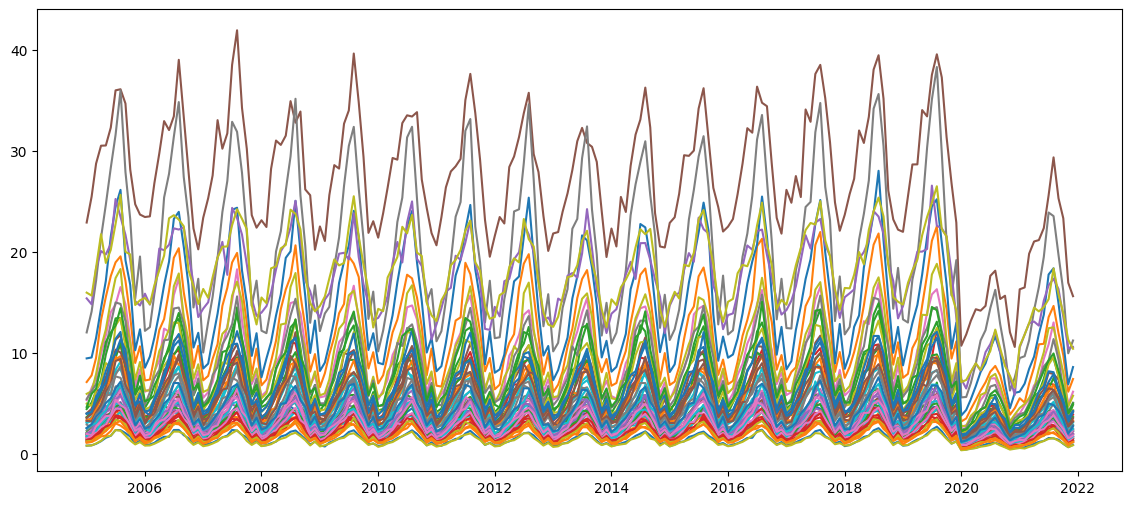

In [4]:
# Crear una fecha mensual que empiece en el 1 del mes
df["fecha_ts"]=pd.to_datetime(df["Year"].astype(str)+"-"+df["Mes"].astype(str)+"-01")
# Agrupamos por provincia y por mes
df_m = df.groupby(["Provincias", "fecha_ts"])["ViajerosxCapita"].mean().reset_index() #Para que provincias y fecha_ts no actuen como indices

#Grafico
fig, ax =plt.subplots(figsize=(14,6))
for prov, grupo in df_m.groupby("Provincias"):
  ax.plot(grupo["fecha_ts"], grupo["ViajerosxCapita"])
plt.show()

# Pregunta 2

**Realiza una representación gráfica ordenada del ranking de provincias de más a menos turismo hotelero per cápita, usando la media de ViajerosxCapita como referencia.**

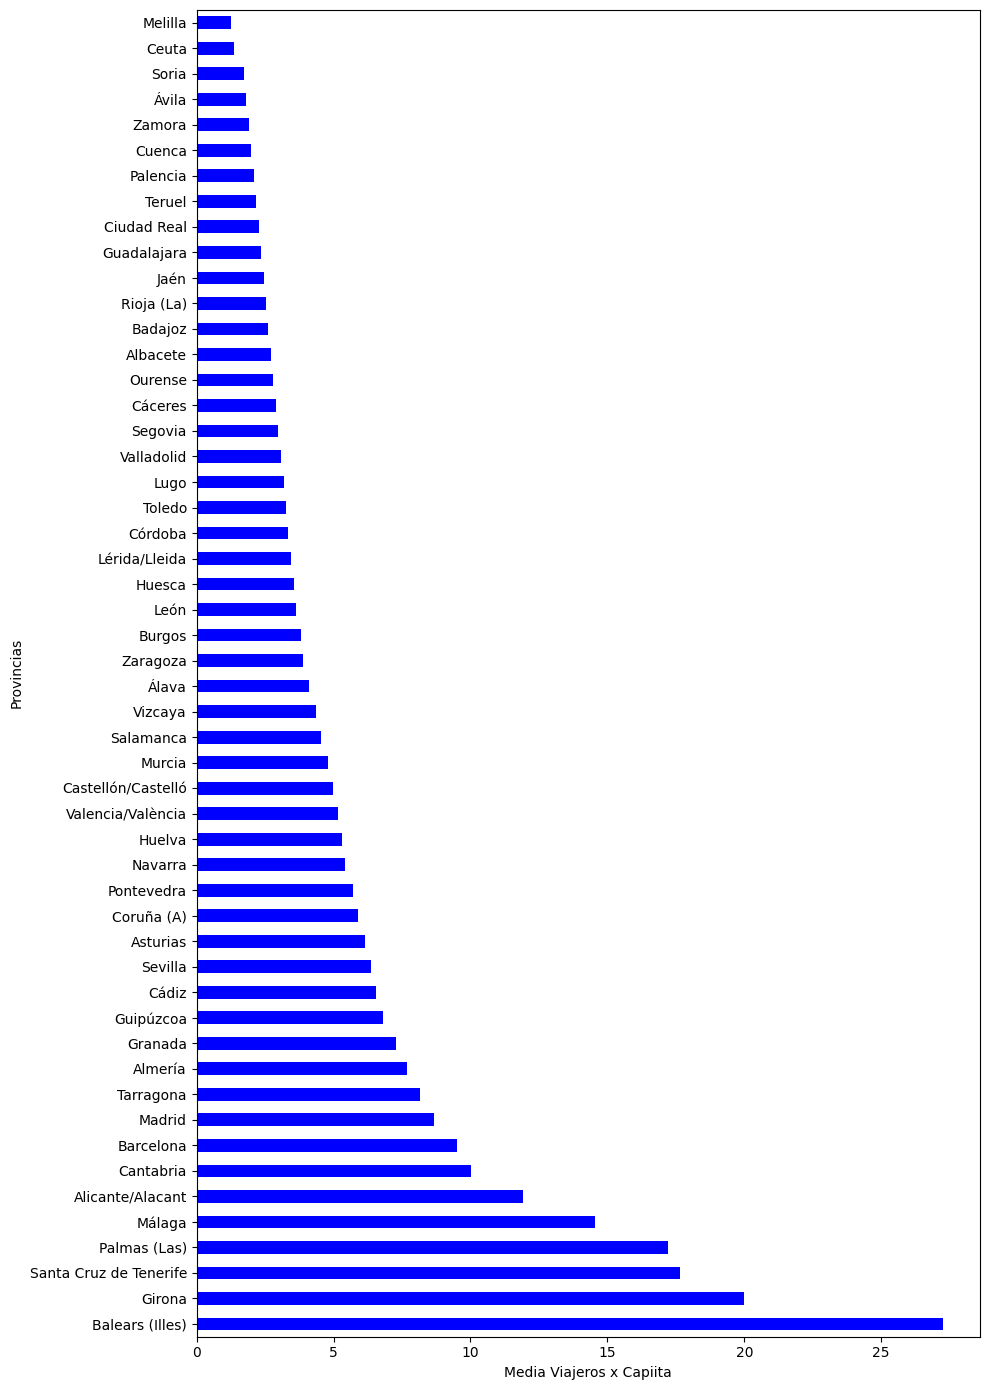

In [5]:
ranking = df.groupby("Provincias")["ViajerosxCapita"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,14))
ranking.plot(kind="barh", ax=ax, color="blue")
ax.set_xlabel("Media Viajeros x Capiita")
plt.tight_layout()
plt.show()

# Pregunta 3

**La dirección general quiere llevar a cabo acciones comerciales diferenciadas por zonas. Por ello, se pregunta: ¿podemos decir que existe convergencia absoluta (el turismo hotelero por provincia se comporta de manera homogénea)? En base a los resultados, ¿qué podemos contestar a la dirección general? ¿Se pueden llevar a cabo acciones diferenciadas?**

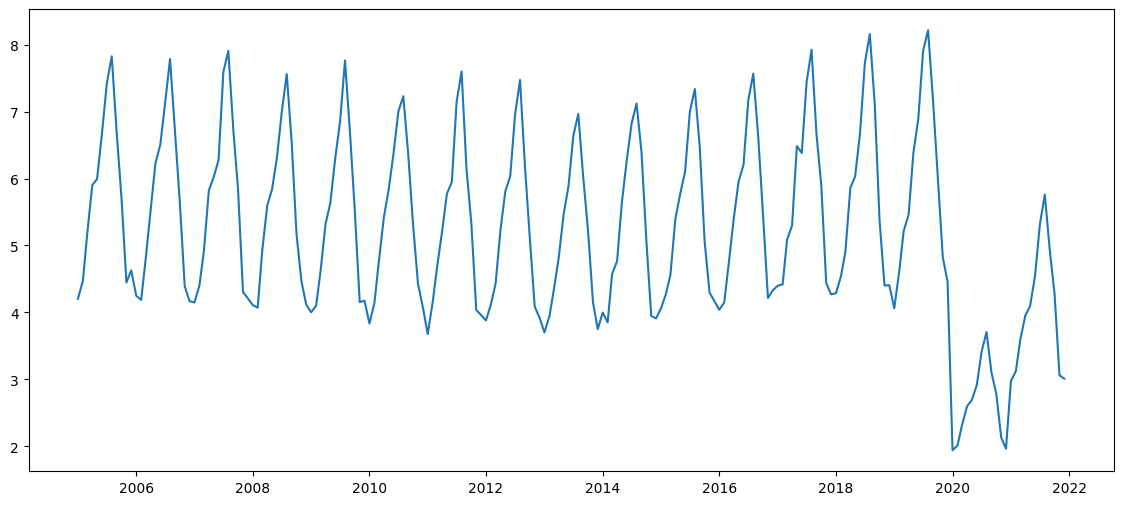

In [6]:
df_m2 = df.groupby(["fecha_ts", "Provincias"])["ViajerosxCapita"].mean().reset_index()

sigma = df_m2.groupby("fecha_ts")["ViajerosxCapita"].std()

fig,ax=plt.subplots(figsize=(14,6))
ax.plot(sigma.index, sigma.values) #El index es fecha_ts
plt.show()

# Pregunta 4:

**En el caso de que no exista convergencia absoluta, ¿en cuántos grupos (clubes) podemos dividir las provincias según el comportamiento de sus series temporales? ¿Existe algún patrón de comportamiento geográfico y/o relacionado con el ranking elaborado en la segunda pregunta?**

In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pivot = df_m.pivot_table(index="Provincias", columns="fecha_ts", values="ViajerosxCapita").fillna(0)
X = StandardScaler().fit_transform(pivot)
X

array([[-0.52897691, -0.53769801, -0.54965216, ..., -0.55954395,
        -0.58113359, -0.61532964],
       [ 0.77043546,  0.80260724,  0.84622904, ...,  1.21176048,
         1.00708218,  1.28907452],
       [ 0.127748  ,  0.19342002,  0.20839671, ...,  0.20478578,
         0.18045727,  0.4299183 ],
       ...,
       [-0.33315449, -0.31086205, -0.41004359, ..., -0.39777074,
        -0.32613025, -0.37010485],
       [-0.32163172, -0.29047897, -0.28943576, ..., -0.29246731,
        -0.36340322, -0.27912723],
       [-0.66241741, -0.68309226, -0.68050071, ..., -0.7503645 ,
        -0.70139566, -0.80550518]])

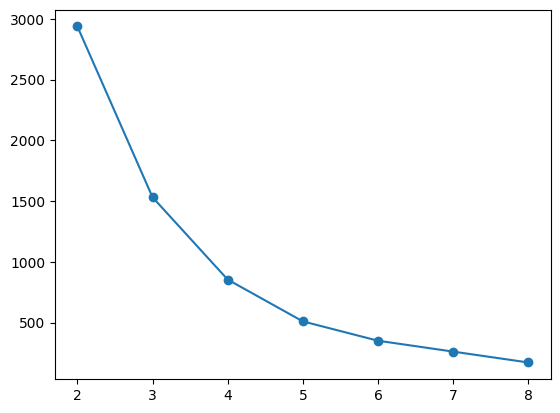

In [8]:
# Metodo del codo
inercias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_ for k in range(2,9)]
plt.plot(range(2,9), inercias, marker="o")
plt.show()

In [9]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
pivot["club"]=km.fit_predict(X)
pivot

fecha_ts,2005-01-01 00:00:00,2005-02-01 00:00:00,2005-03-01 00:00:00,2005-04-01 00:00:00,2005-05-01 00:00:00,2005-06-01 00:00:00,2005-07-01 00:00:00,2005-08-01 00:00:00,2005-09-01 00:00:00,2005-10-01 00:00:00,...,2021-04-01 00:00:00,2021-05-01 00:00:00,2021-06-01 00:00:00,2021-07-01 00:00:00,2021-08-01 00:00:00,2021-09-01 00:00:00,2021-10-01 00:00:00,2021-11-01 00:00:00,2021-12-01 00:00:00,club
Provincias,,,,,,,,,,,,,,,,,,,,,
Albacete,1.673097,1.811630,2.304114,2.763648,3.562876,3.726415,4.119195,4.697549,4.060518,2.805738,...,1.942210,2.324463,2.696308,3.039436,3.653929,2.631937,2.231013,1.307988,1.706025,2
Alicante/Alacant,7.083760,7.742669,9.478223,13.209130,15.499556,17.573072,18.932861,19.527102,17.097549,13.541794,...,8.556518,10.816916,10.868134,13.505904,14.615948,11.929759,9.741974,6.124454,7.384513,0
Almería,4.407654,5.046930,6.200094,7.256914,9.803221,11.568134,13.387871,13.429968,10.975794,7.756874,...,5.668158,6.043945,7.414373,9.176955,9.437007,7.684153,5.472043,3.617609,4.822710,0
Asturias,3.593436,3.910308,5.273923,6.193258,7.508407,7.973993,9.810724,10.766133,8.492594,7.045331,...,4.073593,5.146321,5.888533,6.930608,6.835382,6.319647,4.591153,3.362395,3.846916,0
Badajoz,1.503844,1.746340,2.304598,2.558644,3.286194,3.672991,4.466006,4.885309,3.662226,2.867705,...,1.957128,2.344386,2.500483,3.089289,3.398936,2.459736,2.019720,1.315006,1.501235,2
Balears (Illes),22.872880,25.433968,28.712052,30.478959,30.501306,32.268561,35.958910,36.068171,34.655387,28.111611,...,20.997142,21.137401,22.326972,25.558534,29.325011,25.274756,23.295063,16.914929,15.582767,3
Barcelona,5.287444,6.490194,7.470460,9.888596,11.704680,13.994712,14.748364,16.484468,14.785498,11.242448,...,6.764040,7.121144,9.384270,10.798423,12.984604,9.493587,7.937806,4.817011,6.127484,0
Burgos,2.283769,2.611793,3.338296,3.898416,4.447687,5.088684,6.652369,6.683038,5.819134,4.725189,...,2.530741,3.049122,3.543056,4.160081,4.953983,3.924087,2.754007,1.891223,2.253571,2
Cantabria,5.913481,6.175090,7.872366,10.483539,12.285211,15.086176,17.374142,18.272508,13.380607,11.032017,...,6.415584,8.396037,10.033863,12.413627,12.497425,10.215989,8.010146,4.650765,5.731948,0


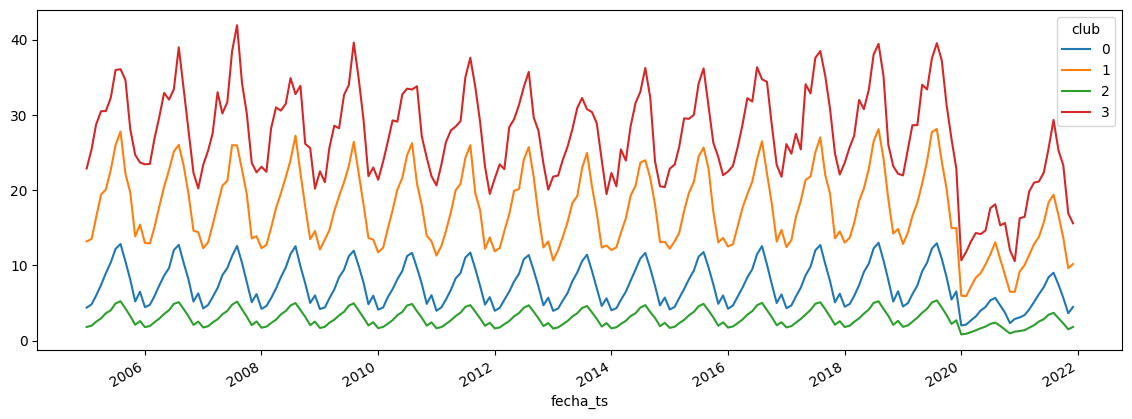

Club 0: Alicante/Alacant, Almería, Asturias, Barcelona, Cantabria, Coruña (A), Cádiz, Granada, Guipúzcoa, Huelva, Madrid, Navarra, Pontevedra, Sevilla, Tarragona, Valencia/València
Club 1: Girona, Málaga, Palmas (Las), Santa Cruz de Tenerife
Club 2: Albacete, Badajoz, Burgos, Castellón/Castelló, Ceuta, Ciudad Real, Cuenca, Cáceres, Córdoba, Guadalajara, Huesca, Jaén, León, Lugo, Lérida/Lleida, Melilla, Murcia, Ourense, Palencia, Rioja (La), Salamanca, Segovia, Soria, Teruel, Toledo, Valladolid, Vizcaya, Zamora, Zaragoza, Álava, Ávila
Club 3: Balears (Illes)


In [10]:
# Series medias por club
clubes=pivot.copy()
medias=clubes.groupby("club").mean().T
medias.plot(figsize=(14,5))
plt.show()

for i in sorted(pivot["club"].unique()):
  provincias_en_club=pivot[pivot["club"]==i].index.tolist()
  print(f"Club {i}: {", ".join(provincias_en_club)}")

# Pregunta 5:

**Realizad una predicción a 12 meses para, como mínimo, una provincia de cada club. Luego comparad si hay clubes cuyas series temporales sean más fácilmente predecibles que otros.**

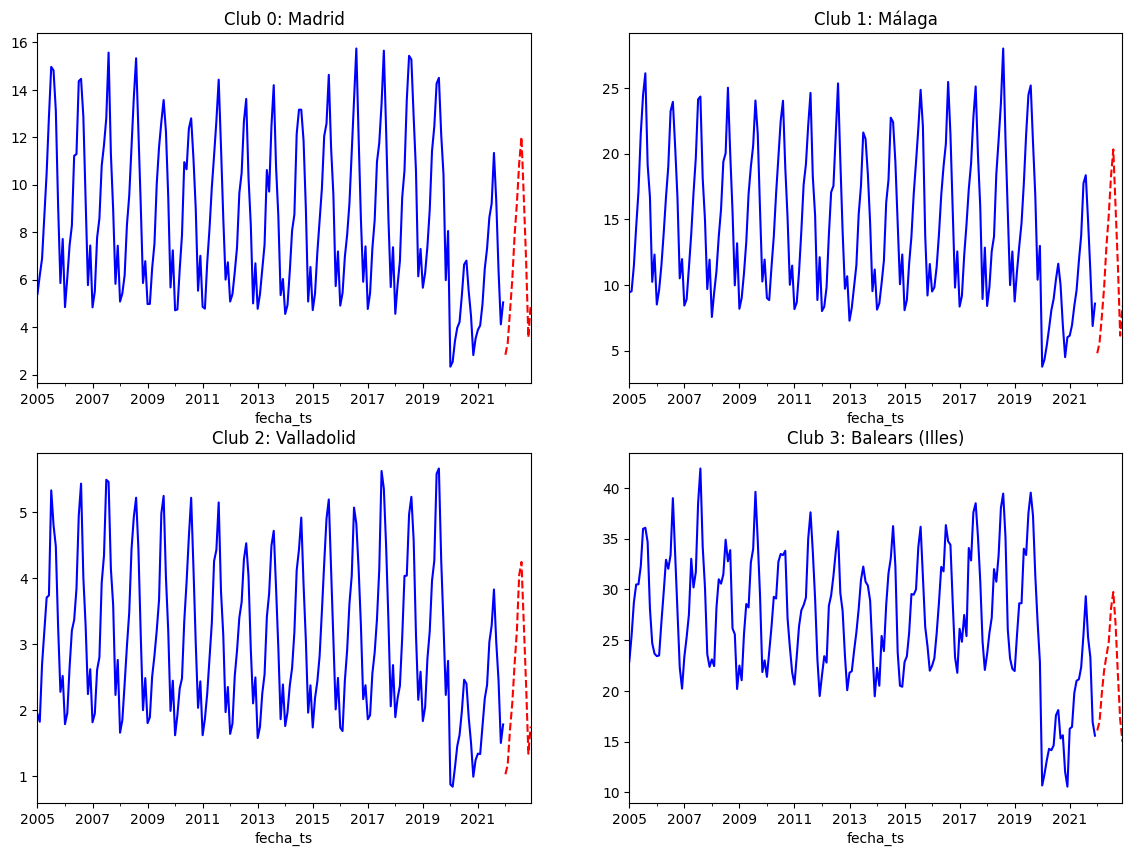

In [11]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

provincias_a_predecir={
    "Club 0": "Madrid",
    "Club 1": "Málaga",
    "Club 2": "Valladolid",
    "Club 3": "Balears (Illes)"
}

fig, axes = plt.subplots(2,2, figsize=(14,10))

for ax, (club,prov) in zip(axes.flat, provincias_a_predecir.items()):
  serie = df_m[df_m["Provincias"]==prov].set_index("fecha_ts")["ViajerosxCapita"]
  serie.index.freq="MS"
  modelo = ExponentialSmoothing(serie, trend="add", seasonal="add", seasonal_periods=12)
  res = modelo.fit()
  pred=res.forecast(12)
  serie.plot(ax=ax, label="Historico", color="blue")
  pred.plot(ax=ax, label="Prediccion 12m", color="red", linestyle="--")
  ax.set_title(f"{club}: {prov}")
plt.show()